In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../../../")
from config.label_matchers import matchers

### Load the data:

In [26]:
df = pd.concat([
    pd.read_csv("CPN.csv", sep=";", names=["text", "label"], encoding_errors="ignore"),
    pd.read_csv("ePurse-selective.csv", sep=";", names=["text", "label"], encoding_errors="ignore"),
    pd.read_csv("GPS.csv", sep=";", names=["text", "label"], encoding_errors="ignore"),
], keys=["CPN", "ePurse", "GPS"], names=["project"]).reset_index(level="project").reset_index(drop=True).reset_index(names="id")

In [27]:
print("Number of instances:", df.shape[0])

Number of instances: 512


In [28]:
df.sample(5)

,id,project,text,label
167,167,CPN,The customer environment (CNG and/or CNDs) sho...,nonsec
355,355,GPS,The Application Provider is responsible for P...,nonsec
488,488,GPS,"""If the card is in the Life Cycle State CARD_...",nonsec
322,322,ePurse,There may be multiple certification authoritie...,sec
368,368,GPS,"""The runtime environment is responsible for P...",sec


In [29]:
idx = df.loc[df["label"] == "xyz"].index
df.drop(idx, inplace=True)

idx = df.loc[df["label"].isna()].index
df.drop(idx, inplace=True)

In [30]:
matcher = {v: k for (k, v) in matchers["safety_requirement"].items()}
df["label"] = df["label"].replace(matcher).astype(int)

/tmp/ipykernel_372125/2644761301.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["label"] = df["label"].replace(matcher).astype(int)


### Clean the data:

In [31]:
print("Number of missing texts:", df["text"].isnull().sum())

Number of missing texts: 0


In [32]:
print("Number of missing labels:", df["label"].isnull().sum())

Number of missing labels: 0


In [33]:
print(f"Number of duplicated texts: {df["text"].duplicated().sum()} ({df["text"].duplicated().sum()/df.shape[0]:.2%})")

Number of duplicated texts: 66 (12.94%)


*WARNING: Duplicated texts are particularly high.*

### Analyze distributions:

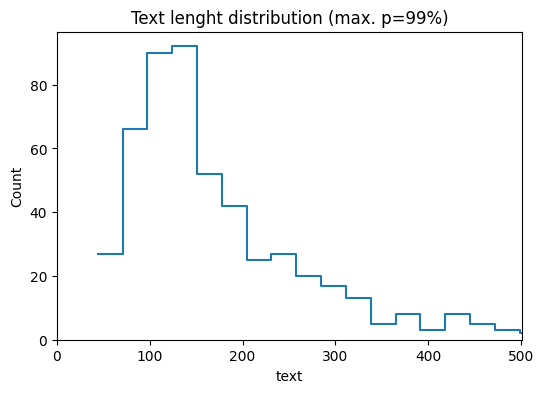

In [34]:
plt.figure(figsize=(6, 4))
sns.histplot(df["text"].str.len(), element="step", fill=False)
plt.xlim([
    0,
    df["text"].str.len().quantile(.99)
])
plt.title("Text lenght distribution (max. p=99%)")
plt.show()

In [35]:
df["label"].value_counts(dropna=False, normalize=True).round(2)

label
0    0.63
1    0.37
Name: proportion, dtype: float64

### Persist datasets:

In [ ]:
df[["id", "project", "text", "label"]].to_parquet("./security_requirement.parquet", index=False)

In [37]:
print("Number of instances in the persisted dataset:", df.shape[0])

Number of instances in the persisted dataset: 510
